# CSE428: Coding Assignment-2

In [1]:
NAME = "Rejwan Shafi"
ID = "23241108"
COLLABORATORS_ID = ["23241108", "24141198"]

This assignment contains 3 tasks. Complete the notebook with proper codes for the lines with `# TO-BE-COMPLETED` tag, or by *uncommenting* a partially written codes where necessary.

## **Task 0: The Imports** <br>
### Import the necessary libraries and define the helper functions. You can use the helper functions from the coding tutorials, or you can even use your own version of helper functions. <br>


In [2]:
# Import libraries
from skimage.io import imread, imshow
from skimage import img_as_float
from skimage import color, filters
#from skimage.util import pad
from skimage.util import random_noise
import numpy as np
from scipy import ndimage, signal
import matplotlib.pyplot as plt

In [3]:
# Define helper functions
def plot_image(img, figsize = (6,6)):
    plt.figure(figsize = figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap = "gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    print("Image shape = {}".format(img.shape))

def plot_kernel(kernel, cmap = "Reds"):
    plt.imshow(kernel, interpolation = "none", cmap = "Reds")
    plt.colorbar()
    plt.show()
    print("Kernel shape = {}".format(kernel.shape))

def gaussian_kernel(width=1, size = 10):
    gaussian1dkernel = signal.gaussian(size,width).reshape(size,1)
    kernel = np.outer(gaussian1dkernel, gaussian1dkernel)
    return kernel/np.sum(kernel)

def box_kernel(size=5):
    return np.ones((size, size))/size**2

## **Task 1: Correlation Vs. Convolution** <br>
### Comparing the correlation and convolution operation for different kernels<br>


To filter an ```image``` with a ```kernel``` all we need to do is call the ```signal.correlate``` function from the ```scipy``` library.

```
filtered_image = signal.correlate(image, kernel, mode='same')
```
Here, ```mode="same"``` takes care of the image padding under the hood; making the filtered image the *same shape* as the input image, while ```mode="valid"``` *shrinks the filtered image*.




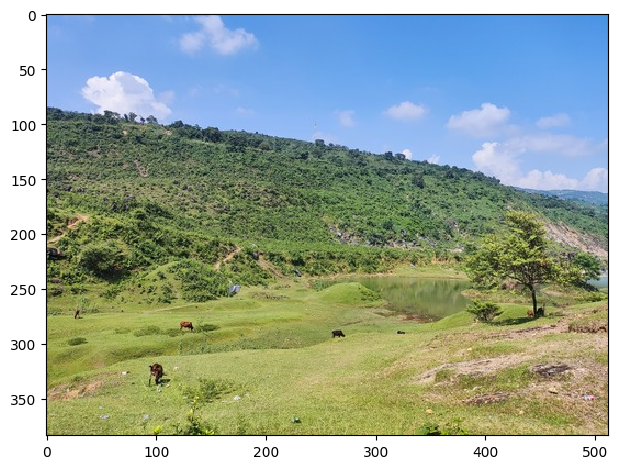

In [10]:
# Import an image taken by you, make sure it's dimensions does not exceed (512, 512). Downsample if necessary.
image = imread("Sample.jpg")
image = image/255
imshow(image)

In [11]:
# Define any symmetric kernel of size (105, 105)
kernel_symmetric = np.zeros((105,105)) # TO-BE-COMPLETED
for i in range(105):
    for j in range(105):
        kernel_symmetric[i][j] = i+j-104
        kernel_symmetric[i][j] = kernel_symmetric[i][j]/104

print(kernel_symmetric)

[[-1.         -0.99038462 -0.98076923 ... -0.01923077 -0.00961538
   0.        ]
 [-0.99038462 -0.98076923 -0.97115385 ... -0.00961538  0.
   0.00961538]
 [-0.98076923 -0.97115385 -0.96153846 ...  0.          0.00961538
   0.01923077]
 ...
 [-0.01923077 -0.00961538  0.         ...  0.96153846  0.97115385
   0.98076923]
 [-0.00961538  0.          0.00961538 ...  0.97115385  0.98076923
   0.99038462]
 [ 0.          0.00961538  0.01923077 ...  0.98076923  0.99038462
   1.        ]]


In [12]:
# Define any asymmetric kernel of size (105, 105)
kernel_asymmetric = np.random.randn(105,105) # TO-BE-COMPLETED
print(kernel_asymmetric)

[[-2.91057333  0.09885863 -1.14509731 ...  0.35165582  0.6771786
  -0.5426049 ]
 [-1.75396194 -0.54516973 -0.80174098 ...  0.88069896  0.85413366
  -0.23294198]
 [-0.30386952 -0.54844624  0.90811668 ... -0.32407786  1.77558328
   0.46569809]
 ...
 [ 0.44396695 -0.47132034 -0.38889216 ...  0.62896328 -0.13083388
  -0.1118242 ]
 [-1.53662009 -1.12809683  1.35689691 ... -0.35339444  0.58670444
   1.57083617]
 [ 0.01323545 -0.65991395  0.57349311 ...  0.86881251  0.01185762
   0.24344215]]


In [13]:
# Filter the image with the symmetric kernel using the correlation function

for i in range(3):
    filtered_image_symmetric = signal.correlate(image[:,:,i], kernel_symmetric, mode = "same", method = "auto")# TO-BE-COMPLETED
    filtered_image_asymmetric = signal.correlate(image[:,:,i], kernel_asymmetric, mode = "same", method = "auto") # TO-BE-COMPLETED

(-0.5, 511.5, 383.5, -0.5)

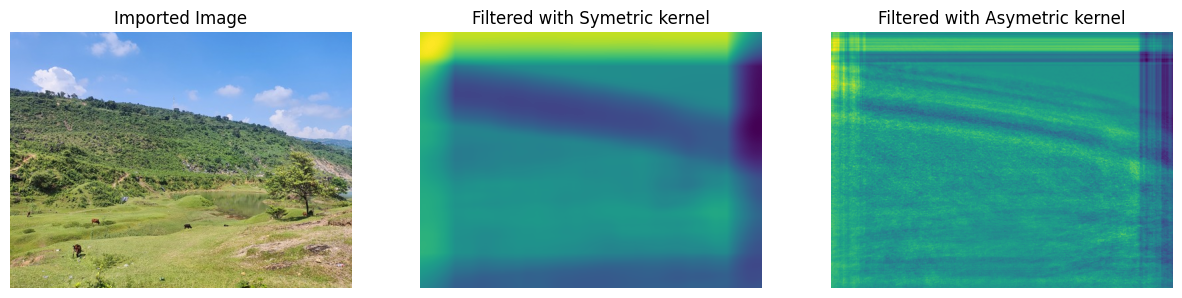

In [14]:
# Display the images side by side (with proper labeling, which is which)
plt.figure(figsize= (15,6))
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis("off")
plt.title("Imported Image")
plt.subplot(1,3,2)
plt.imshow(filtered_image_symmetric)
plt.title("Filtered with Symetric kernel")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(filtered_image_asymmetric)
plt.title("Filtered with Asymetric kernel")
plt.axis("off")

Now, to *convolve* an ```image``` with a ```kernel``` all we need to do is call the ```signal.convolve``` function from the ```scipy``` library.

```
filtered_image = signal.convolve(image, kernel, mode='same')```

The parameters work the same way as the ```signal.correlate```function.

In [15]:
# Filter the image with the asymmetric kernel using the convolution function
for i in range(3):
    filtered_image_symmetric = signal.convolve(image[:,:,i], kernel_symmetric, mode = "same", method = "auto")# TO-BE-COMPLETED
    filtered_image_asymmetric = signal.convolve(image[:,:,i], kernel_asymmetric, mode = "same", method = "auto") # TO-BE-COMPLETED

(-0.5, 511.5, 383.5, -0.5)

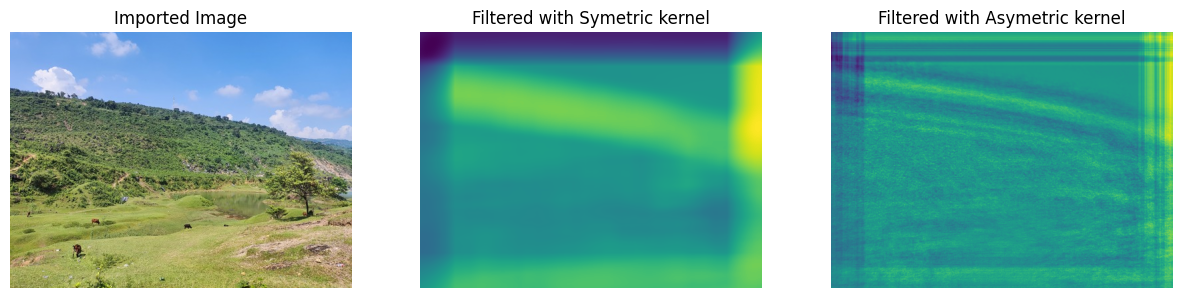

In [16]:
# Display the images side by side (with proper labeling, which is which)
plt.figure(figsize= (15,6))
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis("off")
plt.title("Imported Image")
plt.subplot(1,3,2)
plt.imshow(filtered_image_symmetric)
plt.title("Filtered with Symetric kernel")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(filtered_image_asymmetric)
plt.title("Filtered with Asymetric kernel")
plt.axis("off")

### **Answer to Task 1**

> Indented block


### Compare the outputs of the correlation and convolution operation. Describe the differences you see.

The way correlation and convolution treat the kernel determines the appearance of the final pictures. Correlation highlights areas in the picture that match the kemel, whereas convolution smoothes the image by mixing close values. This distinction can influence how prominent things look in the filtered photos. In addition, when utilising asymmetrical kemels, the differences between correlation and convolution outputs may be more obvious than when using symmetrical kemels.

## **Task 2: Edge Pair Detector** <br>


### **Task 2.1:**
Try to come up with two 3 x 3 filter kernels which are able to detect ***only the parallel pair of edges*** in the following image. <br><br>

*Hint: No mathematical derivation is necessary. Just try devising the kernels using the same intuitions used behind the horizontal and vertical edge detector kernels. Coming up with a filter kernel means to determine the 9 filter coefficients of the 3x3 filer kernel.*

![](https://drive.google.com/uc?export=view&id=1a1CXbuC8A2FbyFvZovJMXERUijpatecU)

[The image can be downloaded from here: https://drive.google.com/file/d/1a1CXbuC8A2FbyFvZovJMXERUijpatecU/view?usp=sharing]

In [17]:
# Download the image from the drive link above and upload it to your current working directory in colab. Then load the image

image = imread("diamond2.jpg") # TO-BE-COMPLETED
image = image/255
image = color.rgb2gray(image)

In [18]:
# define the 2 custom kernels by replacing the "?"s with your values and uncomment the next few lines of code in this cell
kernel_1 = np.array([[0, 1, 2], # TO-BE-COMPLETED
                     [-1, 0, 1], # TO-BE-COMPLETED
                     [-2, -1, 0]]) # TO-BE-COMPLETED

kernel_2 = np.array([[2, 1, 0], # TO-BE-COMPLETED
                     [1, 0, -1], # TO-BE-COMPLETED
                     [0, -1, -2]]) # TO-BE-COMPLETED

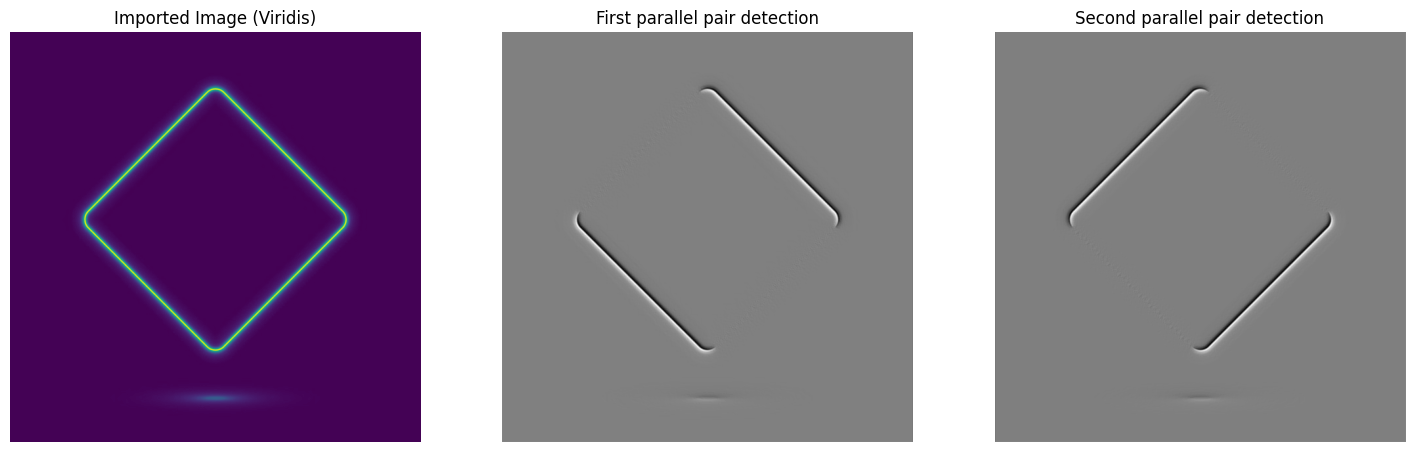

In [19]:
# detect the 2 parallel pair of edges and plot them side by side in a 1x2 grid subplot

# detect the first pair using image filtering with kernel_1

first_pair_detected = signal.correlate(image, kernel_1, mode = 'same', method = 'auto') # TO-BE-COMPLETED

# detect the second pair using image filtering with kernel_2

second_pair_detected =signal.correlate(image, kernel_2, mode = 'same', method = 'auto')  # TO-BE-COMPLETED

# plot the two filtered images side by side

plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(image, cmap='viridis')
plt.axis("off")
plt.title("Imported Image (Viridis)")

plt.subplot(1,3,2)
plt.imshow(first_pair_detected, cmap='gray')
plt.title("First parallel pair detection")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(second_pair_detected, cmap='gray')
plt.title("Second parallel pair detection")
plt.axis("off")

plt.savefig('parallel_lines.png')

### **Answer to Task 2.1**
### Which filters you came up with and why? How did you choose the coefficients? Are your kernels unique or there can be other kernels which can accomplish the same task?

I used the Sobel mask to detect diagonal edges. I did not use the Prewitt since Sobel masks have slightly better noise-suppression properties. Then I kept changing the coefficients unless I get a good result. My kernels are not unique; other kernels, such as Prewitt's and Robinson Compass Masks, may be capable of doing the same work.

### **Task 2.2**

Imagine the output of the Horizontal and Vertical edge detectors being $E_x$ and $E_y$. Devise a quantity as:
$$E_{xy} = \sqrt{E_x^2 + E_y^2}$$
Compute the quantity $E_{xy}$ for the above image and visualize the output.

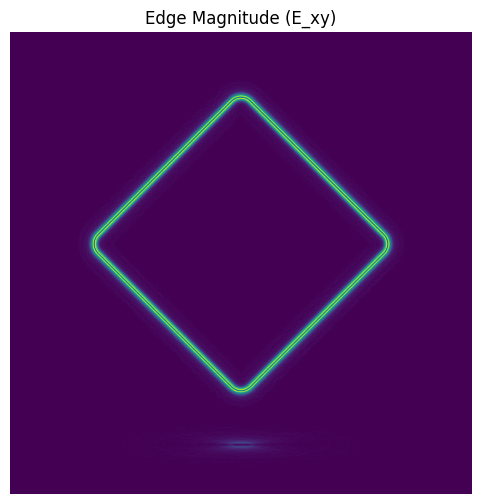

In [20]:
# horizontal edges
horizontal_edges = filters.sobel_h(image)
Ex = horizontal_edges
# vertical edges
vertical_edges = filters.sobel_v(image)
Ey = vertical_edges
# E_xy
E_xy = np.sqrt(Ex**2 + Ey**2)

# Visualize E_xy

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(E_xy, cmap='viridis')
ax.set_title('Edge Magnitude (E_xy)')
ax.axis('off')
plt.show()

#### **Answer to Task 2.2**
### What do you see in the above visualization? Does the quantity $E_{xy}$ make sense for detecting parallel edge pairs in the above image? How does it compare with the edge detector kernel you designed in Task 2.1?

The Exy visualization shows strong edges in both horizontal and vertical orientations. It performs similarly to a single-edge detector built of two. It assists in determining the image's parallel edges. Exy offers greater flexibility than our prior edge detector, Kemel in Task 2.1 . The capacity to detect edges independent of orientation improves edge detection from various angles.


# Task 3: Noise Reduction/Denoising

(i) Noisy Image: https://drive.google.com/file/d/1I1ye90IggplNRVVtZfFTLXLqQWJNGbCM/view?usp=sharing <br>
 (ii) Just Noise: https://drive.google.com/file/d/13AMtZR8ZCGHVcsw7tOJBgSFDnDhgtL9b/view?usp=sharing

 For image (i), your task is to smoothen the image to get as low noise as possible. For image (ii), your task is to get an almost flat intensity image

* From scipy.ndimage use "gaussian_filter" to denoise two given images. Tune the 'sigma' value to obtain different smoothening gaussian kernels. This will give you various degrees of denoising.
* From scipy.ndimage use "median_filter" to denoise the two given images. Try changing the window size of the median filter. This will give you various degrees of denoising.

In [21]:
from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter

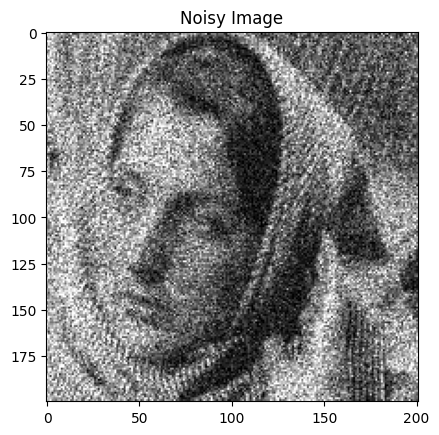

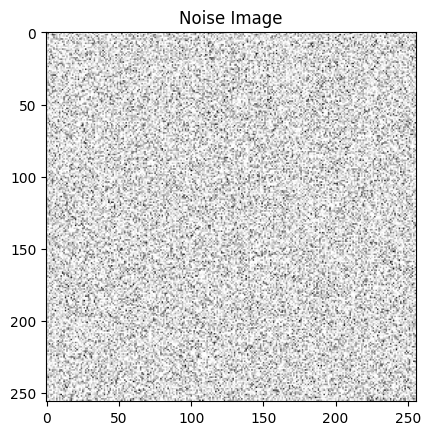

In [22]:
# Download the image from the drive link above and upload it to your current working directory in colab. Then load the image
image1 = imread('Noisy Image.png', as_gray=True)
plt.figure()
plt.imshow(image1, cmap='gray')
plt.title('Noisy Image')

image2 = imread('Noise.png', as_gray=True)
plt.figure()
plt.imshow(image2, cmap='gray')
plt.title('Noise Image')

plt.show()

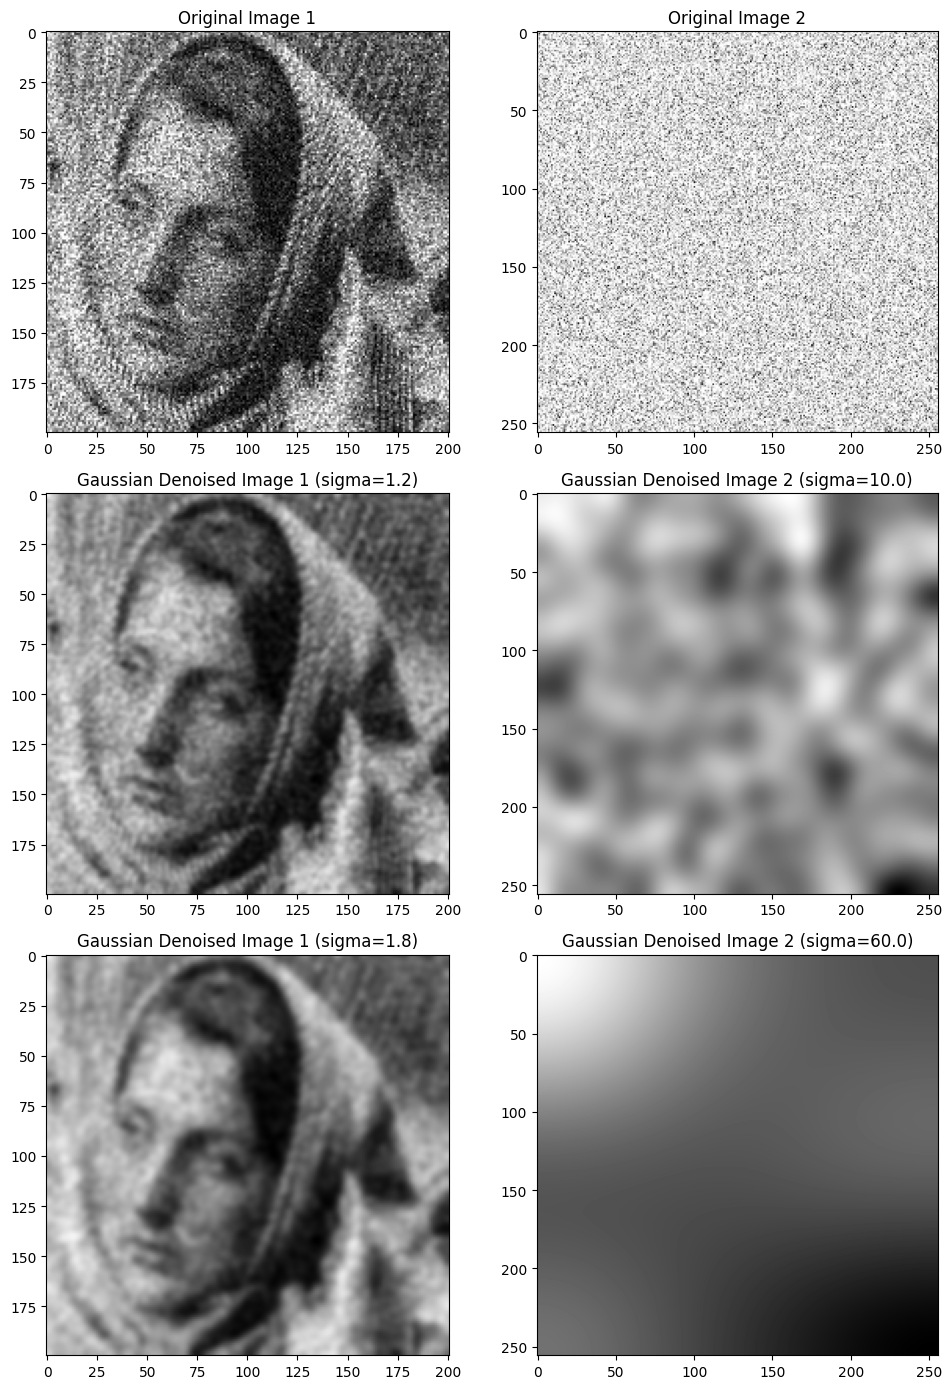

In [37]:
# gaussian filter for denoising

# denoised image with gaussian filter

gaussian_filtered1 = gaussian_filter(image1, sigma=1.2)
gaussian_filtered2 = gaussian_filter(image2, sigma=10.0)

# Median filtering
median_denoised_image1 = median_filter(image1, size=3)
median_denoised_image2 = median_filter(image2, size=3)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 14))

axes[0, 0].imshow(image1, cmap='gray')
axes[0, 0].set_title('Original Image 1')

axes[0, 1].imshow(image2, cmap='gray')
axes[0, 1].set_title('Original Image 2')

axes[1, 0].imshow(gaussian_filtered1, cmap='gray')
axes[1, 0].set_title('Gaussian Denoised Image 1 (sigma=1.2)')

axes[1, 1].imshow(gaussian_filtered2, cmap='gray')
axes[1, 1].set_title('Gaussian Denoised Image 2 (sigma=10.0)')

# Adjusting sigma for further denoising
gaussian_filtered1 = gaussian_filter(image1, sigma=1.8)
gaussian_filtered2 = gaussian_filter(image2, sigma=60.0)

axes[2, 0].imshow(gaussian_filtered1, cmap='gray')
axes[2, 0].set_title('Gaussian Denoised Image 1 (sigma=1.8)')

axes[2, 1].imshow(gaussian_filtered2, cmap='gray')
axes[2, 1].set_title('Gaussian Denoised Image 2 (sigma=60.0)')

plt.tight_layout()
plt.show()


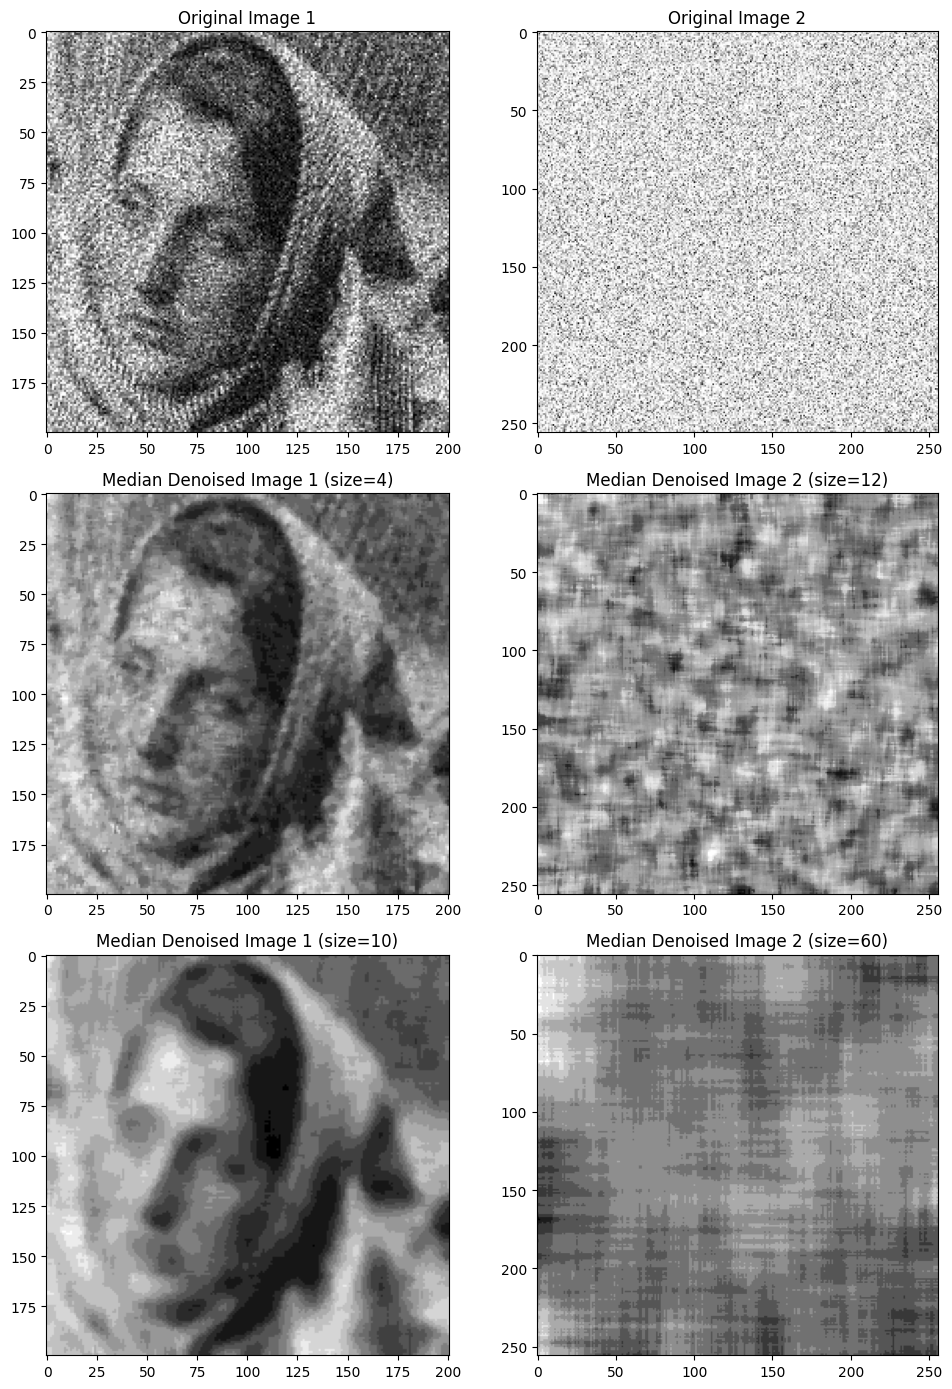

In [46]:
# median filter for denoising
# denoised image with median filter
median_filtered1 = median_filter(image1, size=4)
median_filtered2 = median_filter(image2, size=12)
# Visulaize the denoising
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 14))

axes[0, 0].imshow(image1, cmap='gray')
axes[0, 0].set_title('Original Image 1')

axes[0, 1].imshow(image2, cmap='gray')
axes[0, 1].set_title('Original Image 2')

axes[1, 0].imshow(median_filtered1, cmap='gray')
axes[1, 0].set_title('Median Denoised Image 1 (size=4)')

axes[1, 1].imshow(median_filtered2, cmap='gray')
axes[1, 1].set_title('Median Denoised Image 2 (size=12)')

# Adjusting window size for further denoising
median_filtered1 = median_filter(image1, size=10)
median_filtered2 = median_filter(image2, size=60)

axes[2, 0].imshow(median_filtered1, cmap='gray')
axes[2, 0].set_title('Median Denoised Image 1 (size=10)')

axes[2, 1].imshow(median_filtered2, cmap='gray')
axes[2, 1].set_title('Median Denoised Image 2 (size=60)')

plt.tight_layout()
plt.show()


### **Answer to Task 3**
* For gaussian smoothing how much 'sigma' value for each image was good enough for denosing in your opinion? How do too high or too low 'sigma' values influence the images?
* For median filter what size of the kernel was good enough for denosing in your opinion? How do too big or too small sized median filter influence the images?
* When would you use gaussian filter vs median filter? Explain your reasoning.


### ***Gaussian Filter***
While I was doing the gaussian smoothing of the both picture I found that sigma value of 1.2 work best for image (i), maintaining clarity and reducing noise. For the second image sigma value of 10.0 provided effective denoising. Too high of a sigma value can lead to excessive blurring, causing loss of image sharpness and detail. Conversely, too low of a sigma value may not effectively remove noise, leaving the image still noisy


---


### ***Median Filter***
While I was doing the median filter for both picture I found that a 4x4 kernel size proved effective for denoising and preserving image details for image (i) and a 12x12 kernel proved effective for image (ii). Larger kernel sizes, such as 10x10, caused over-smoothing and loss of detail, while smaller sizes, like 2x2, didnt provide adequate noise reduction. Threfore, using a very large kernel size can result in oversmoothing and loss of fine details in the image. Conversely, a very small kernel size may not effectively remove noise, especially if the noise is spread over a larger area.



---
'

'

Gaussian filter is suitable for removing Gaussian noise, which is additive noise that follows a Gaussian distribution. It is effective for smoothing images while preserving edges and details. Median filter is effective for removing impulse noise, also known as salt-and-pepper noise. It replaces each pixel's value with the median value of its neighborhood, which helps in preserving edges and fine details while removing outliers. If the noise in the image is Gaussian in nature, Gaussian filter is preferred. However, if the noise is non-Gaussian or contains outliers, median filter may be more effective.
In some cases, a combination of both filters can be used, such as applying a Gaussian filter to remove Gaussian noise followed by a median filter to remove remaining impulse noise

## **The END**